In [127]:
import fmatoolbox as fma
from math import *
import matplotlib.pyplot as plt
import numpy as np
import regions as rg
from scipy import signal
from scipy.stats import spearmanr
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [128]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'

In [129]:
R = rg.data.Regions(session,states=['sws','rem'],events=['ripples'])

In [130]:
size, intervals, size_t, profiles = R.avalanches(regs=None,states=None,thresh=0,window=0.05,step=1,smooth=None, profile=True)

In [36]:
size

{np.str_('hpc'): array([ 15.,   6.,   1., ...,   2.,  73., 134.], shape=(78003,)),
 np.str_('nr'): array([37.,  5.,  5., ...,  3., 29., 58.], shape=(66601,)),
 np.str_('pfc'): array([10.,  6., 13., ...,  6., 59.,  5.], shape=(113596,))}

Préparation des arrays de corrélation

In [131]:
def centered_size(size, profiles):
   # print(len(size),len(profiles))
    S=[0 for i in range(len(profiles))]
    indp=0
    inds=0
    while indp < len(profiles):
        if profiles[indp]==0:
            indp+=1
        else:
            inddeb = indp
            while indp< len(profiles) and profiles[indp]!=0:
                indp+=1
            indS= (indp+inddeb)//2
            S[indS] = size[inds]
            inds+=1
    return S



In [132]:
Snr = centered_size(size["nr"], profiles["nr"])
print(size["nr"][:5])
print(profiles["nr"][:20])
print(Snr[:20])

[1.729e+04 8.792e+03 1.000e+00 4.000e+00 4.000e+00]
[180. 260. 300. 200. 280. 340. 160. 120. 160. 220. 120. 120. 140. 240.
 140. 100. 240. 240. 160. 140.]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [133]:
Spfc = centered_size(size["pfc"], profiles["pfc"])
Shpc = centered_size(size["hpc"], profiles["hpc"])

In [134]:
len(Snr), len(Spfc), len(Shpc), max(Snr), len(size["nr"])

(533708, 533708, 533708, np.float64(501033.00000000006), 12985)

In [135]:
k=0
for i in Snr:
    if i!=0:
        k+=1
k

12985

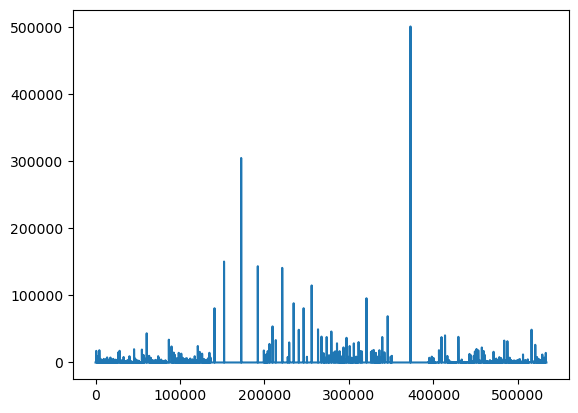

In [136]:
plt.plot(Snr)
plt.show()

Corrélation

In [21]:
def plotCorr(ax, S1, S2, taumax, threshold = 0.005,label1='S1', label2='S2', title='Cross-corrélation', bin_size=0.05, log=False):
    # calcul de la cross-corrélation normalisée
    s1 = np.array(S1)
    s2 = np.array(S2)

    # normalisation
    s1 = (s1 - np.mean(s1)) / (np.std(s1) * len(s1))
    s2 = (s2 - np.mean(s2)) / np.std(s2)

    corr = signal.correlate(s1, s2, mode='full')
    taus = signal.correlation_lags(len(s1), len(s2), mode='full')*bin_size

    # restreindre à [-taumax, taumax]
    tau_mask = (taus >= -taumax) & (taus <= taumax)
    taus = taus[tau_mask]
    corr = corr[tau_mask]

    ax.plot(taus, corr)

    mask = corr > threshold
    ax.plot(taus[mask], corr[mask], 'r-')
    ax.axhline(threshold, color='r', linestyle='--', linewidth=0.8)

    ax.set_xlabel('τ')
    ax.set_ylabel('Corr(' + label1 + ', ' + label2 + '(·+τ))')
    ax.set_title(title)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)

    if log:
        ax.set_yscale('log')

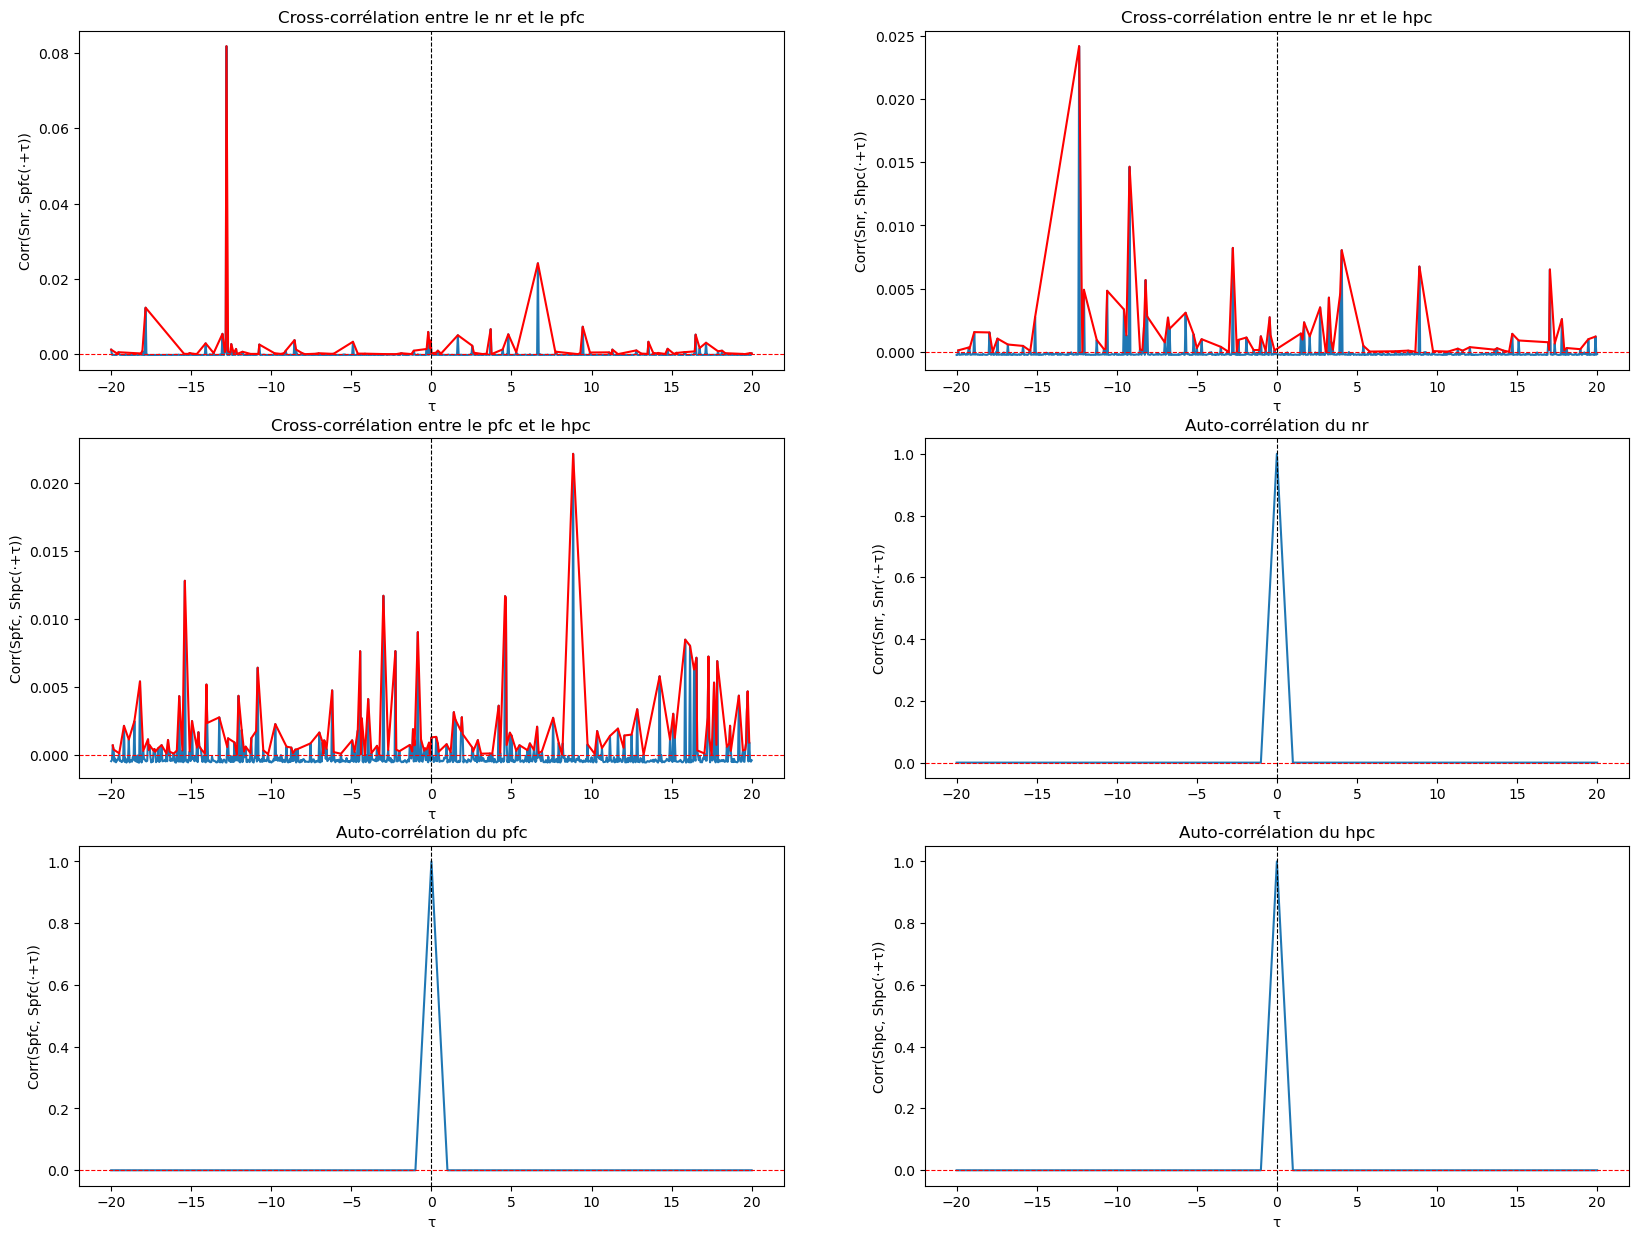

In [23]:
fig, axs = plt.subplots(3, 2, figsize=(20, 15))
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()
tm=20
threshold = 0

plotCorr(ax1,Snr, Spfc, tm, threshold, "Snr", "Spfc", "Cross-corrélation entre le nr et le pfc")
plotCorr(ax2,Snr, Shpc, tm, threshold, "Snr", "Shpc", "Cross-corrélation entre le nr et le hpc")
plotCorr(ax3,Spfc, Shpc, tm, threshold, "Spfc", "Shpc", "Cross-corrélation entre le pfc et le hpc")

plotCorr(ax4,Snr, Snr, tm, threshold, "Snr", "Snr", "Auto-corrélation du nr", True)
plotCorr(ax5,Spfc, Spfc, tm, threshold, "Spfc", "Spfc", "Auto-corrélation du pfc", True)
plotCorr(ax6,Shpc, Shpc, tm, threshold, "Shpc", "Shpc", "Auto-corrélation du hpc", True)

plt.show()

In [143]:
def SpearmanCorr(S1, S2, taumax=None, zone=None):
    s1 = np.array(S1)
    s2 = np.array(S2)
    
    if zone is not None:#zone est un intervalle d'indices, pas de temps 
        s1=s1[zone[0]:zone[1]]
        s2=s2[zone[0]:zone[1]]

    stat = []
    pv = []
    lags = range(max(-(len(s2)-1), -taumax), min(len(s1)-1, taumax)+1)
    
    for i in lags:
        if i >= 0:
            a = s1[i:]
            b = s2[:len(s2)-i] if i > 0 else s2
        else:
            a = s1[:len(s1)+i]
            b = s2[-i:]
        res = spearmanr(a, b)
        stat.append(res.statistic)
        pv.append(res.pvalue)
    
    return np.array(stat), np.array(pv), np.array(list(lags))

In [ ]:
tm=50
stat, pv, lags = SpearmanCorr(Snr, Spfc, tm)

In [145]:
stat[:5], pv[:5], lags

(array([0.04477917, 0.04797767, 0.04662693, 0.05229313, 0.04712277]),
 array([6.16765171e-235, 2.01985123e-269, 1.44090888e-254, 0.00000000e+000,
        5.68095018e-260]),
 array([-50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38,
        -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25,
        -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12,
        -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,
          2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
         15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
         41,  42,  43,  44,  45,  46,  47,  48,  49,  50]))

In [140]:

def plotSpearmanCorr(ax1, ax2, S1, S2, stat, pv,lags,taumax, threshold = 0.005, bin_size=0.05, label1='S1', label2='S2', title='Spearman Correlation', log=False):
    if stat is None or pv is None:
        stat, pv, lags = SpearmanCorr(S1, S2, taumax)

    stat = np.array(stat)
    pv   = np.array(pv)
    taus = lags#np.arange(max(-taumax,int(lags[0])), min(taumax+1, int(lags[-1])+1))
    taus=taus*bin_size
    print(taus)

    ax1.plot(taus, stat, 'b-', label='Spearman r')
    ax2.plot(taus, pv,   'g-', label='p-value')
    
   # mask = stat > threshold
    #ax1.plot(taus[mask], stat[mask], 'r-')
   # ax1.axhline(threshold, color='r', linestyle='--', linewidth=0.8)

    ax1.set_xlabel('τ')
    ax1.set_ylabel('SpearmanCorr(' + label1 + ', ' + label2 + '(·+τ))')
    ax2.set_xlabel('τ')
    ax2.set_ylabel('p-value')
    ax1.set_title(title)
    ax1.axvline(0, color='k', linestyle='--', linewidth=0.8)

    if log:
        ax1.set_yscale('log')

[-2.5  -2.45 -2.4  -2.35 -2.3  -2.25 -2.2  -2.15 -2.1  -2.05 -2.   -1.95
 -1.9  -1.85 -1.8  -1.75 -1.7  -1.65 -1.6  -1.55 -1.5  -1.45 -1.4  -1.35
 -1.3  -1.25 -1.2  -1.15 -1.1  -1.05 -1.   -0.95 -0.9  -0.85 -0.8  -0.75
 -0.7  -0.65 -0.6  -0.55 -0.5  -0.45 -0.4  -0.35 -0.3  -0.25 -0.2  -0.15
 -0.1  -0.05  0.    0.05  0.1   0.15  0.2   0.25  0.3   0.35  0.4   0.45
  0.5   0.55  0.6   0.65  0.7   0.75  0.8   0.85  0.9   0.95  1.    1.05
  1.1   1.15  1.2   1.25  1.3   1.35  1.4   1.45  1.5   1.55  1.6   1.65
  1.7   1.75  1.8   1.85  1.9   1.95  2.    2.05  2.1   2.15  2.2   2.25
  2.3   2.35  2.4   2.45  2.5 ]


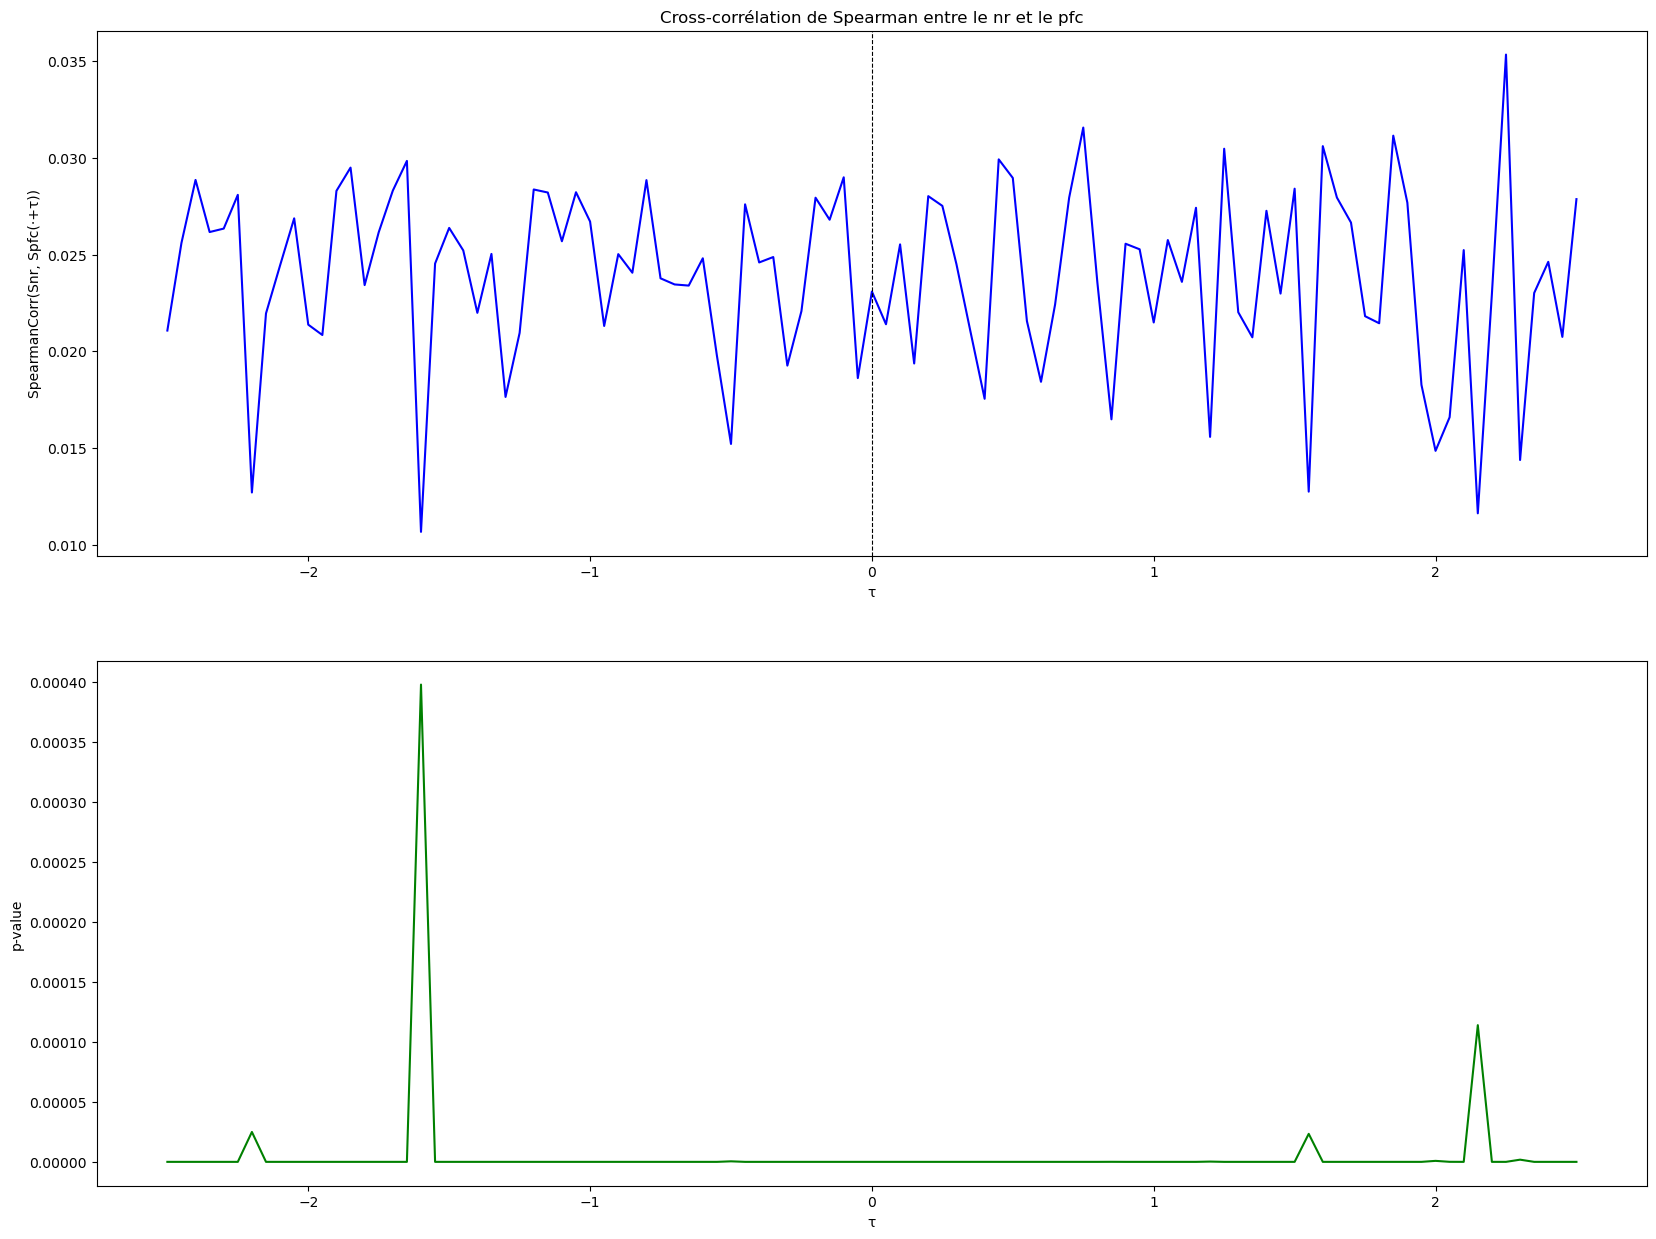

In [149]:
fig, axs = plt.subplots(2, 1, figsize=(20, 15))
ax1, ax2 = axs.flatten()
tm=50
threshold = 0
stat, pv, lags = SpearmanCorr(Snr, Spfc, tm, zone=[0,110000])
plotSpearmanCorr(ax1, ax2 ,Snr, Spfc, stat, pv, lags, tm, threshold, 0.05, "Snr", "Spfc", "Cross-corrélation de Spearman entre le nr et le pfc")
plt.show()

Chevauchement des intervals

In [81]:
intervals

{np.str_('hpc'): array([[2.5000000e-02, 7.5000000e-02],
        [1.2500000e-01, 1.7500000e-01],
        [2.7500000e-01, 3.2500000e-01],
        ...,
        [2.6684125e+04, 2.6684175e+04],
        [2.6684275e+04, 2.6684725e+04],
        [2.6684775e+04, 2.6685425e+04]], shape=(78003, 2)),
 np.str_('nr'): array([[2.5000000e-02, 3.7500000e-01],
        [4.2500000e-01, 5.2500000e-01],
        [6.7500000e-01, 7.2500000e-01],
        ...,
        [2.6684175e+04, 2.6684225e+04],
        [2.6684325e+04, 2.6684775e+04],
        [2.6684825e+04, 2.6685425e+04]], shape=(66601, 2)),
 np.str_('pfc'): array([[2.5000000e-02, 2.7500000e-01],
        [3.2500000e-01, 4.2500000e-01],
        [4.7500000e-01, 7.2500000e-01],
        ...,
        [2.6683975e+04, 2.6684175e+04],
        [2.6684225e+04, 2.6685275e+04],
        [2.6685325e+04, 2.6685375e+04]], shape=(113596, 2))}

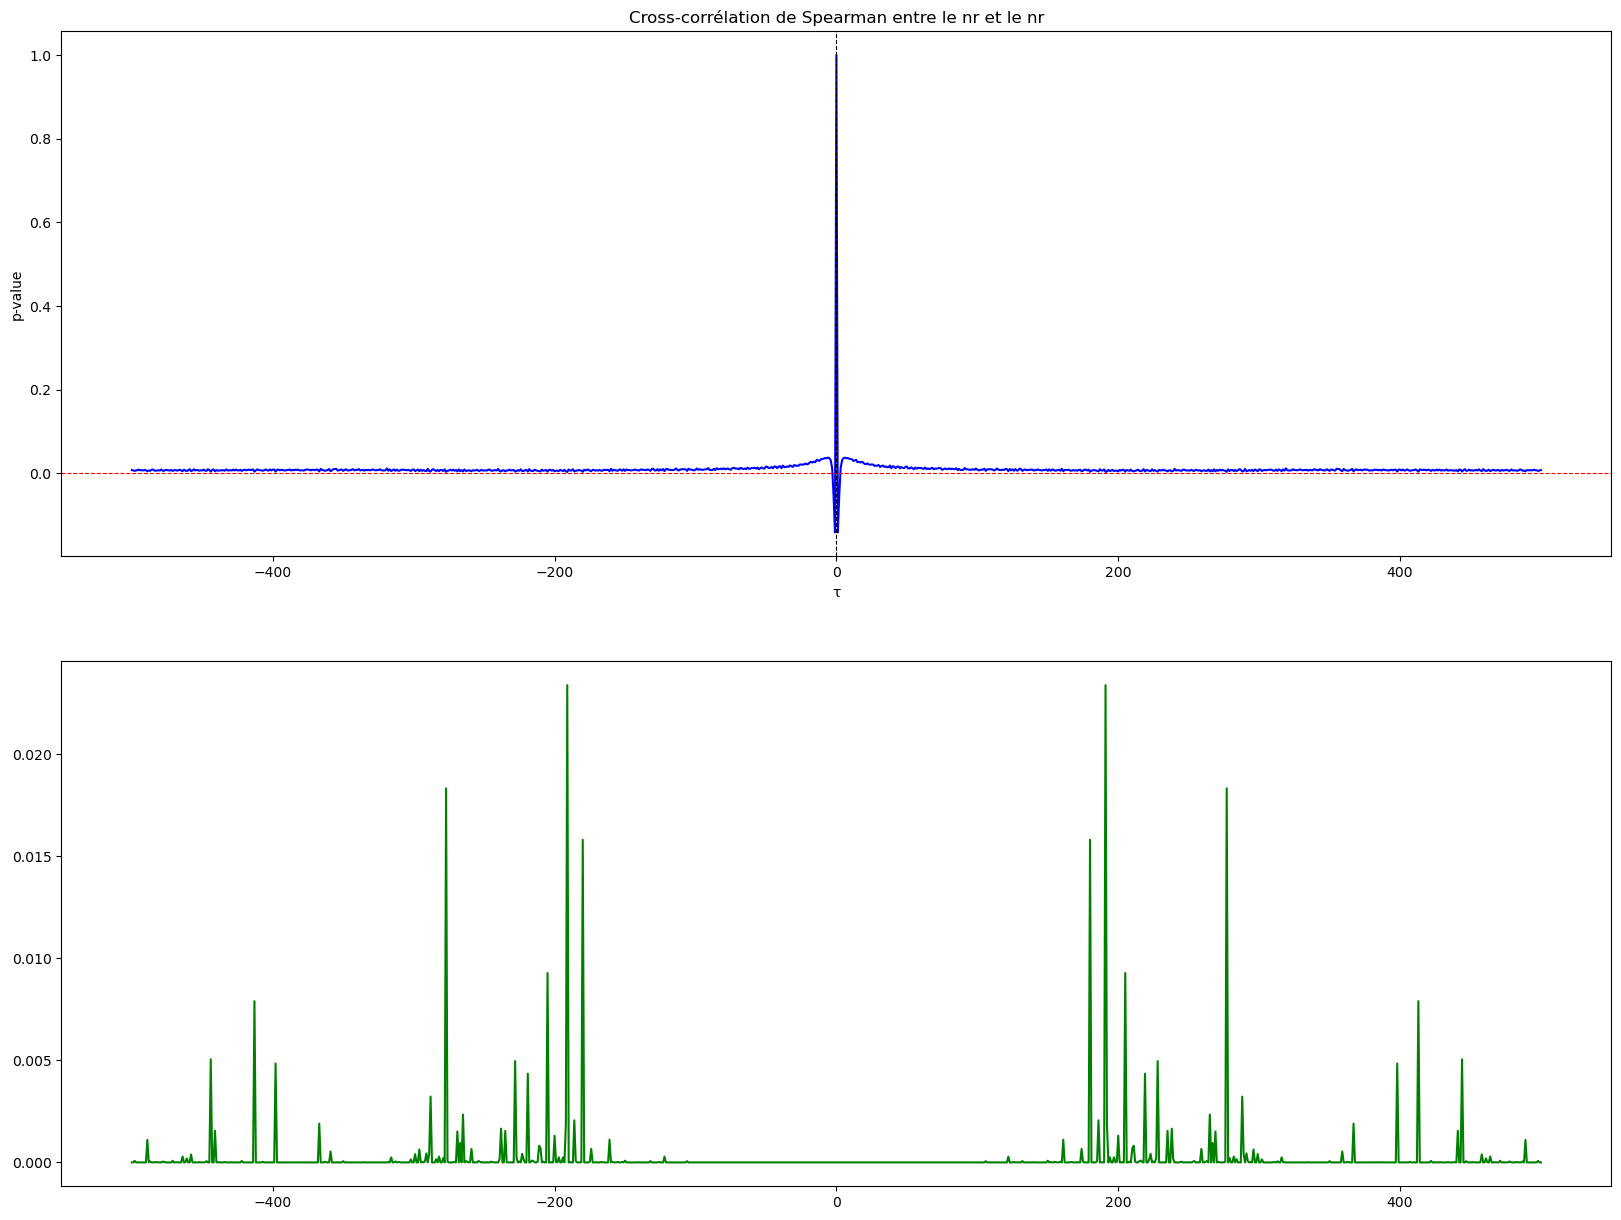

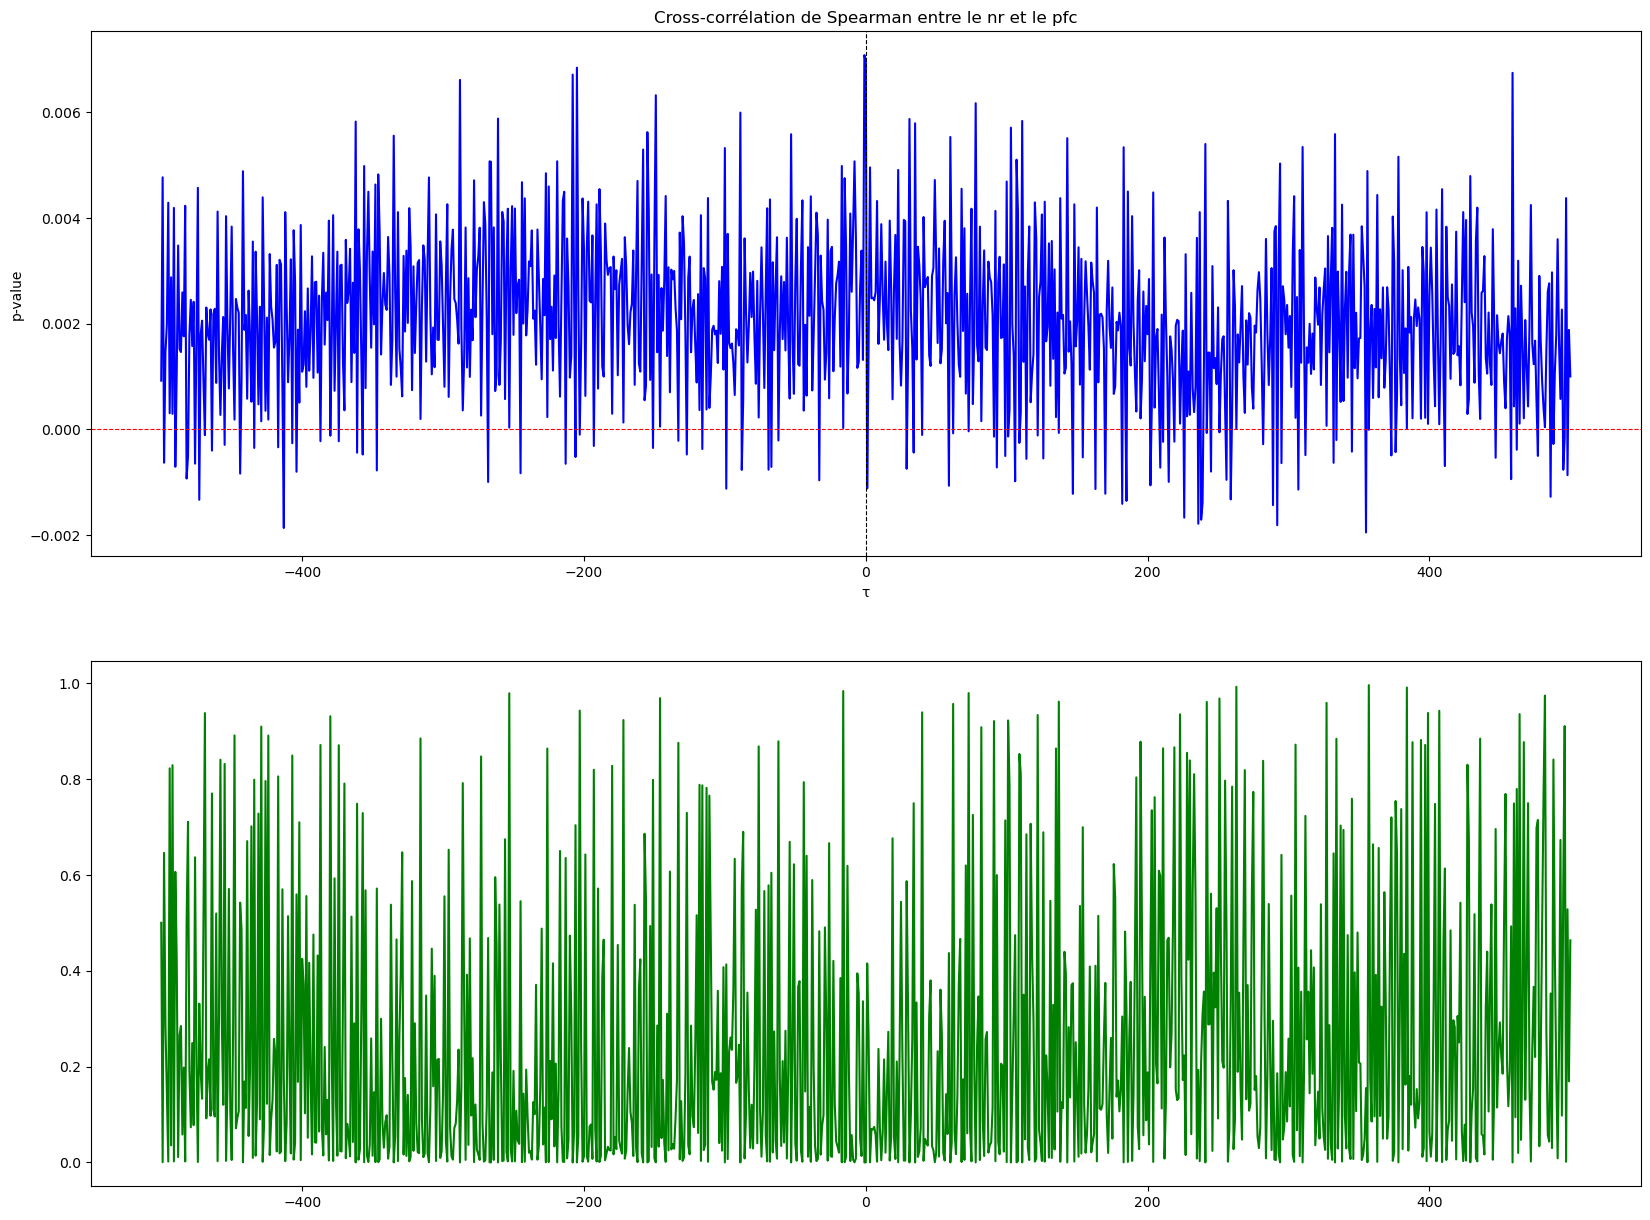

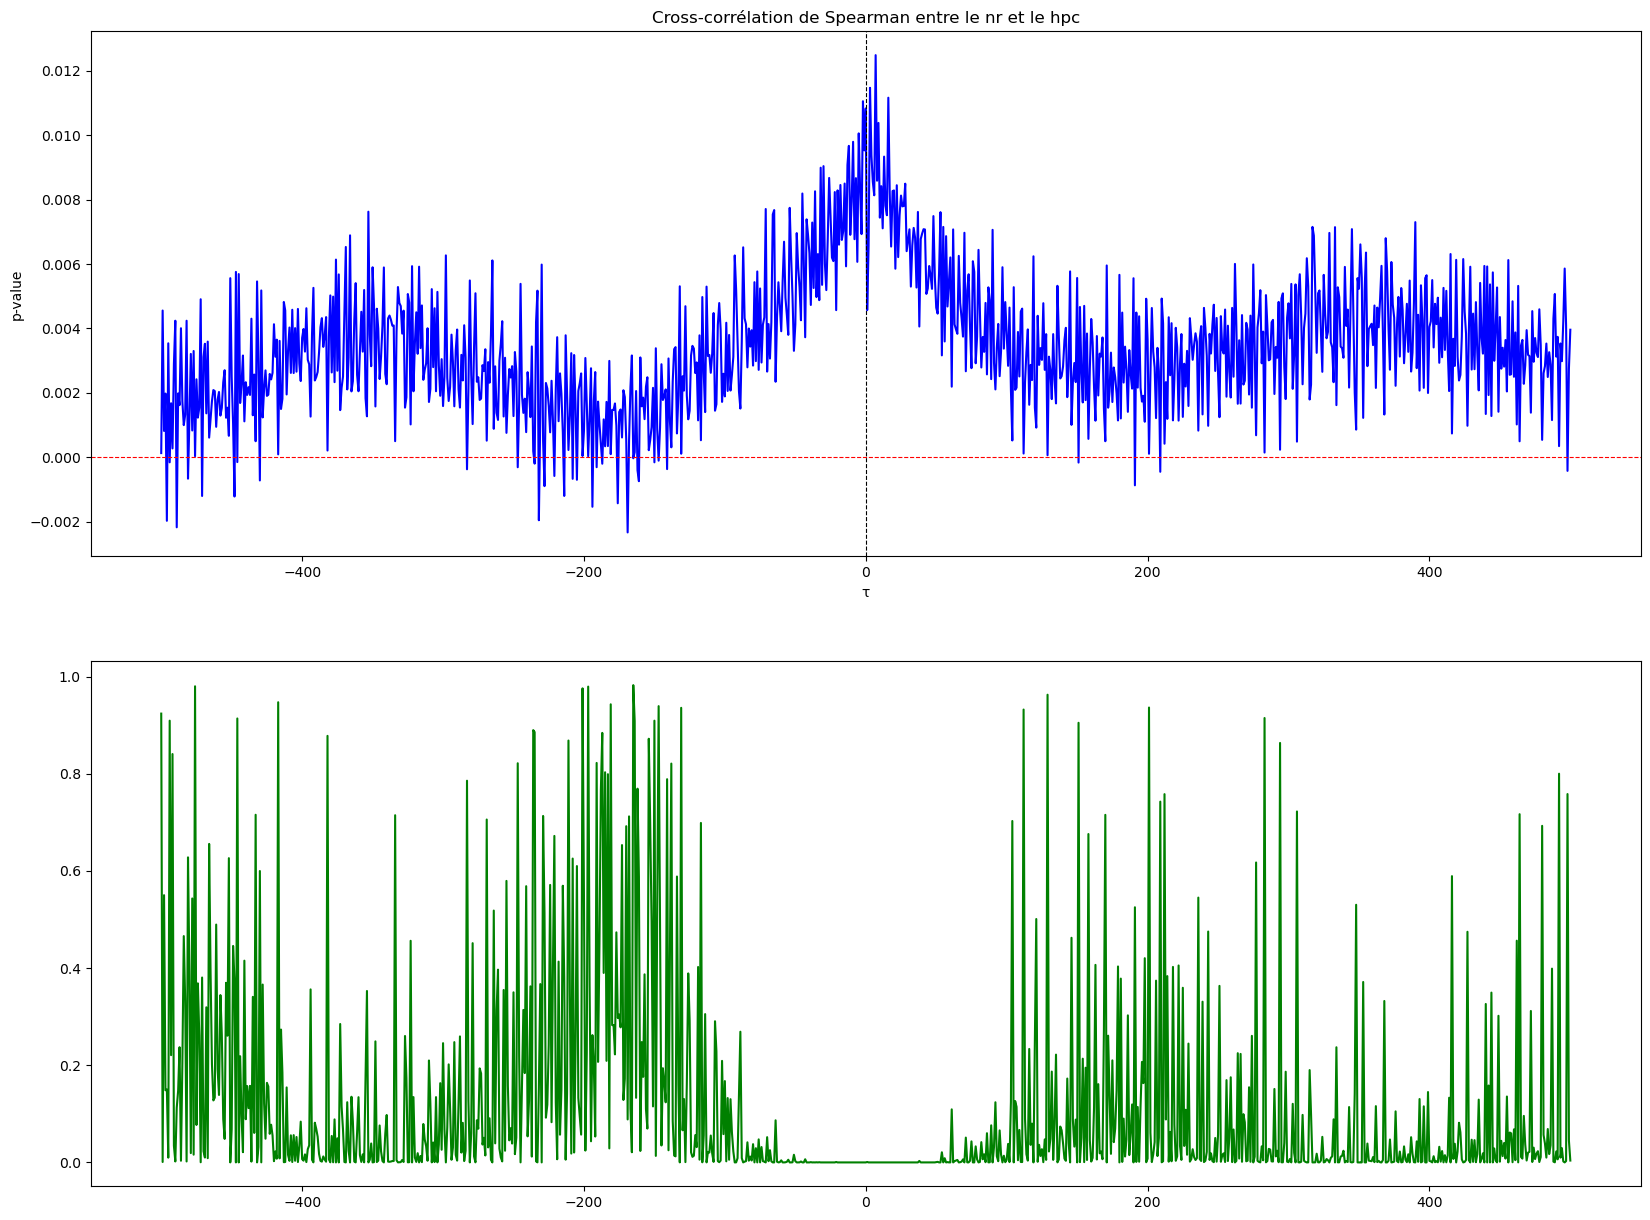

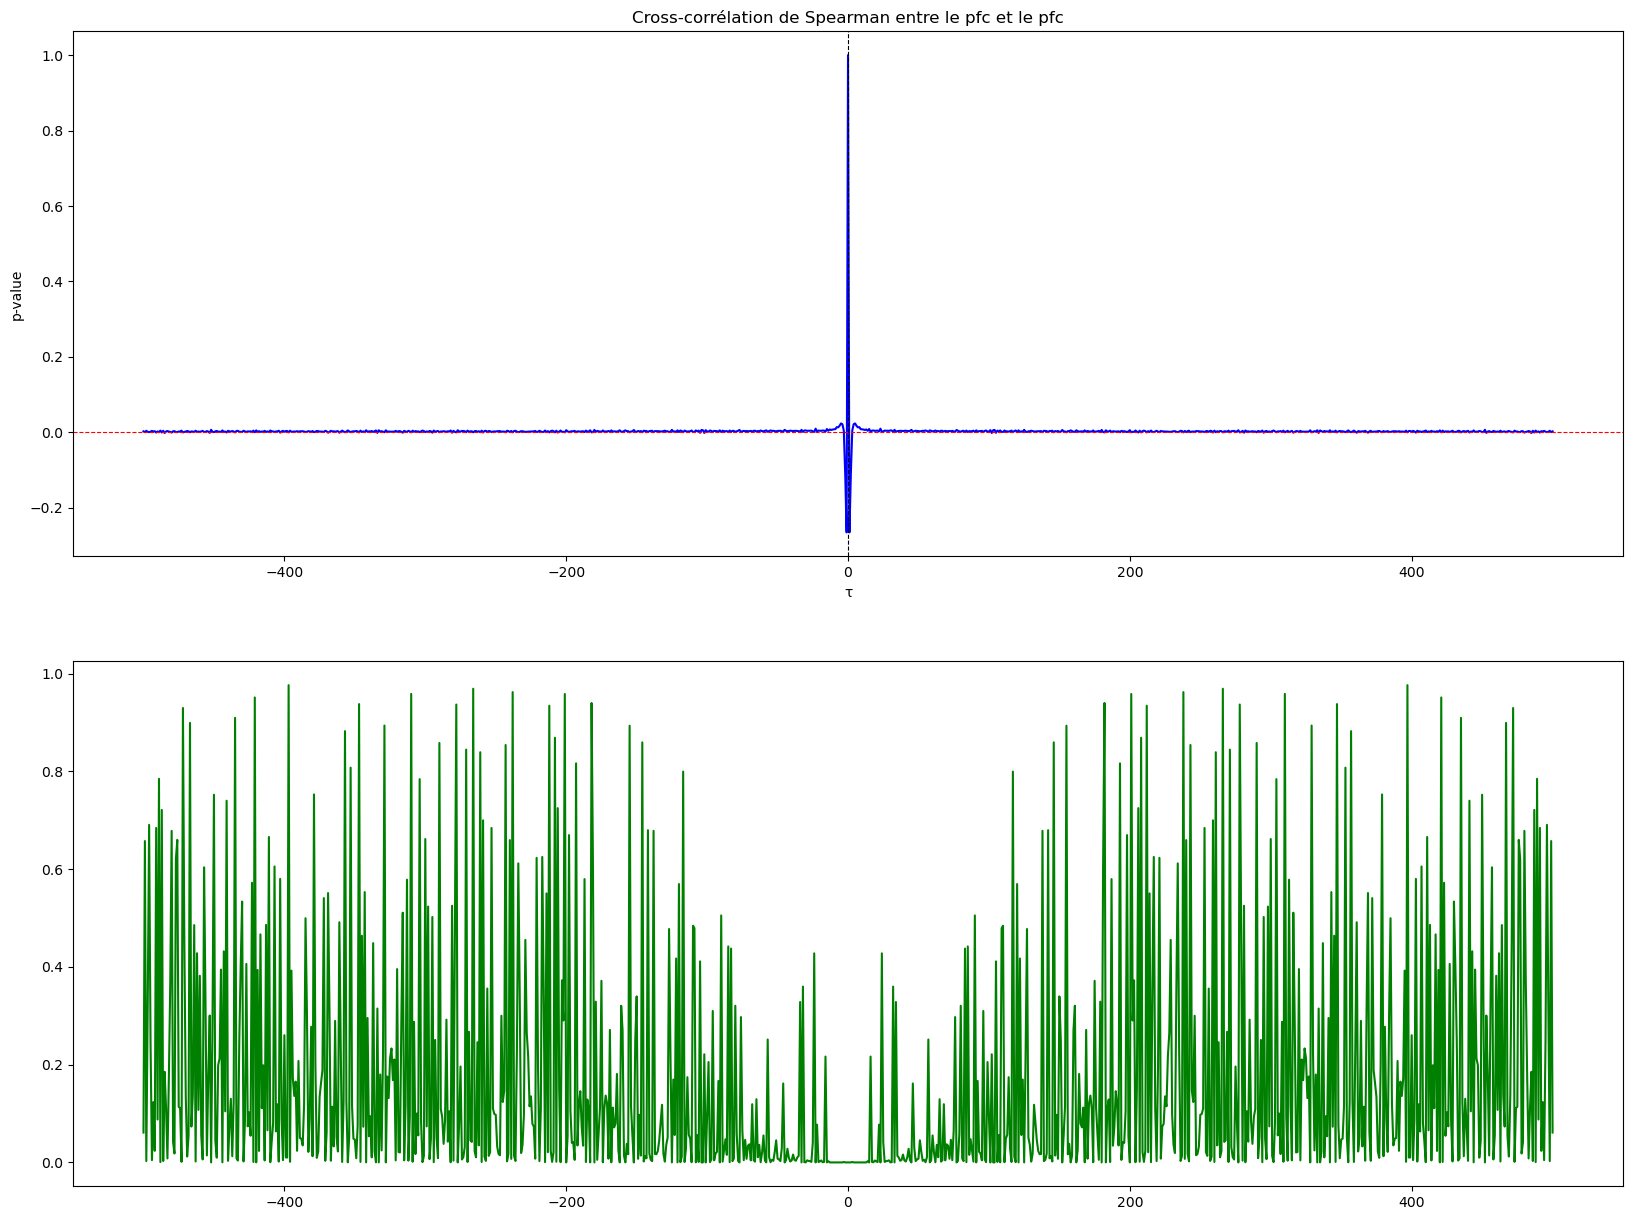

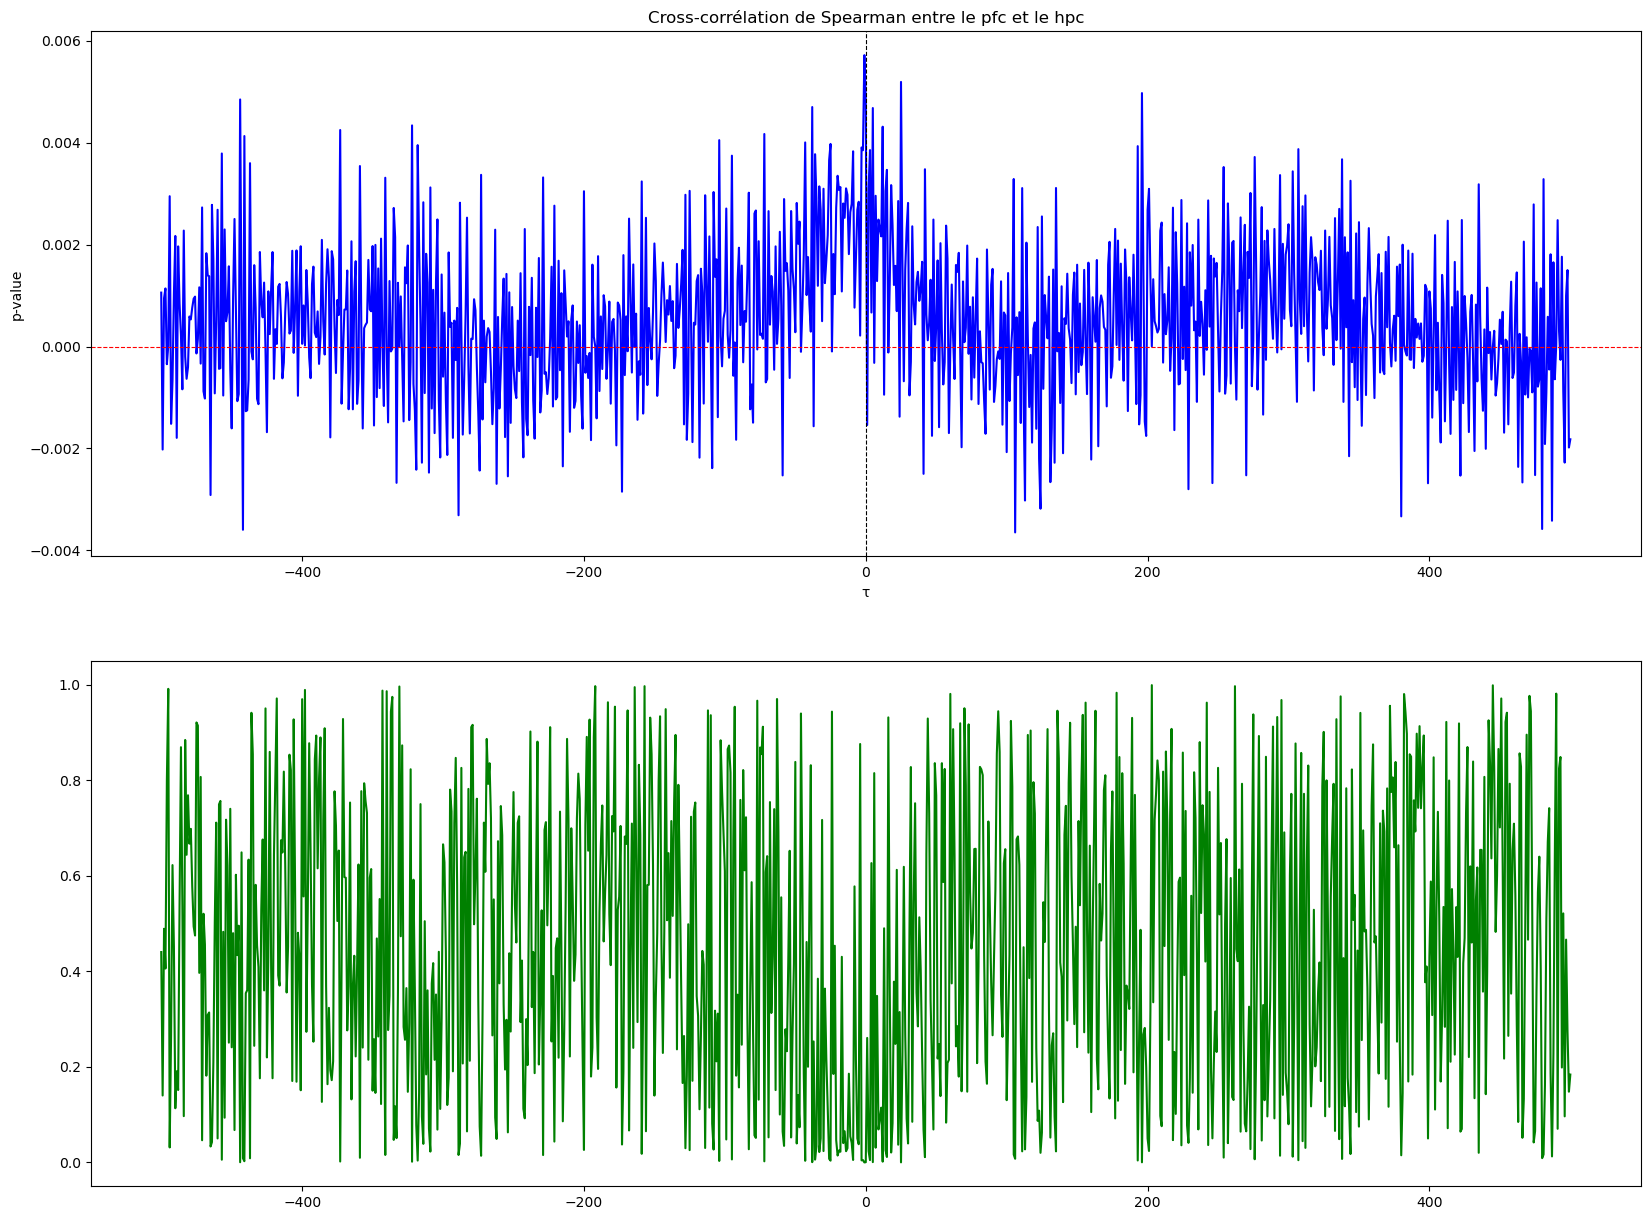

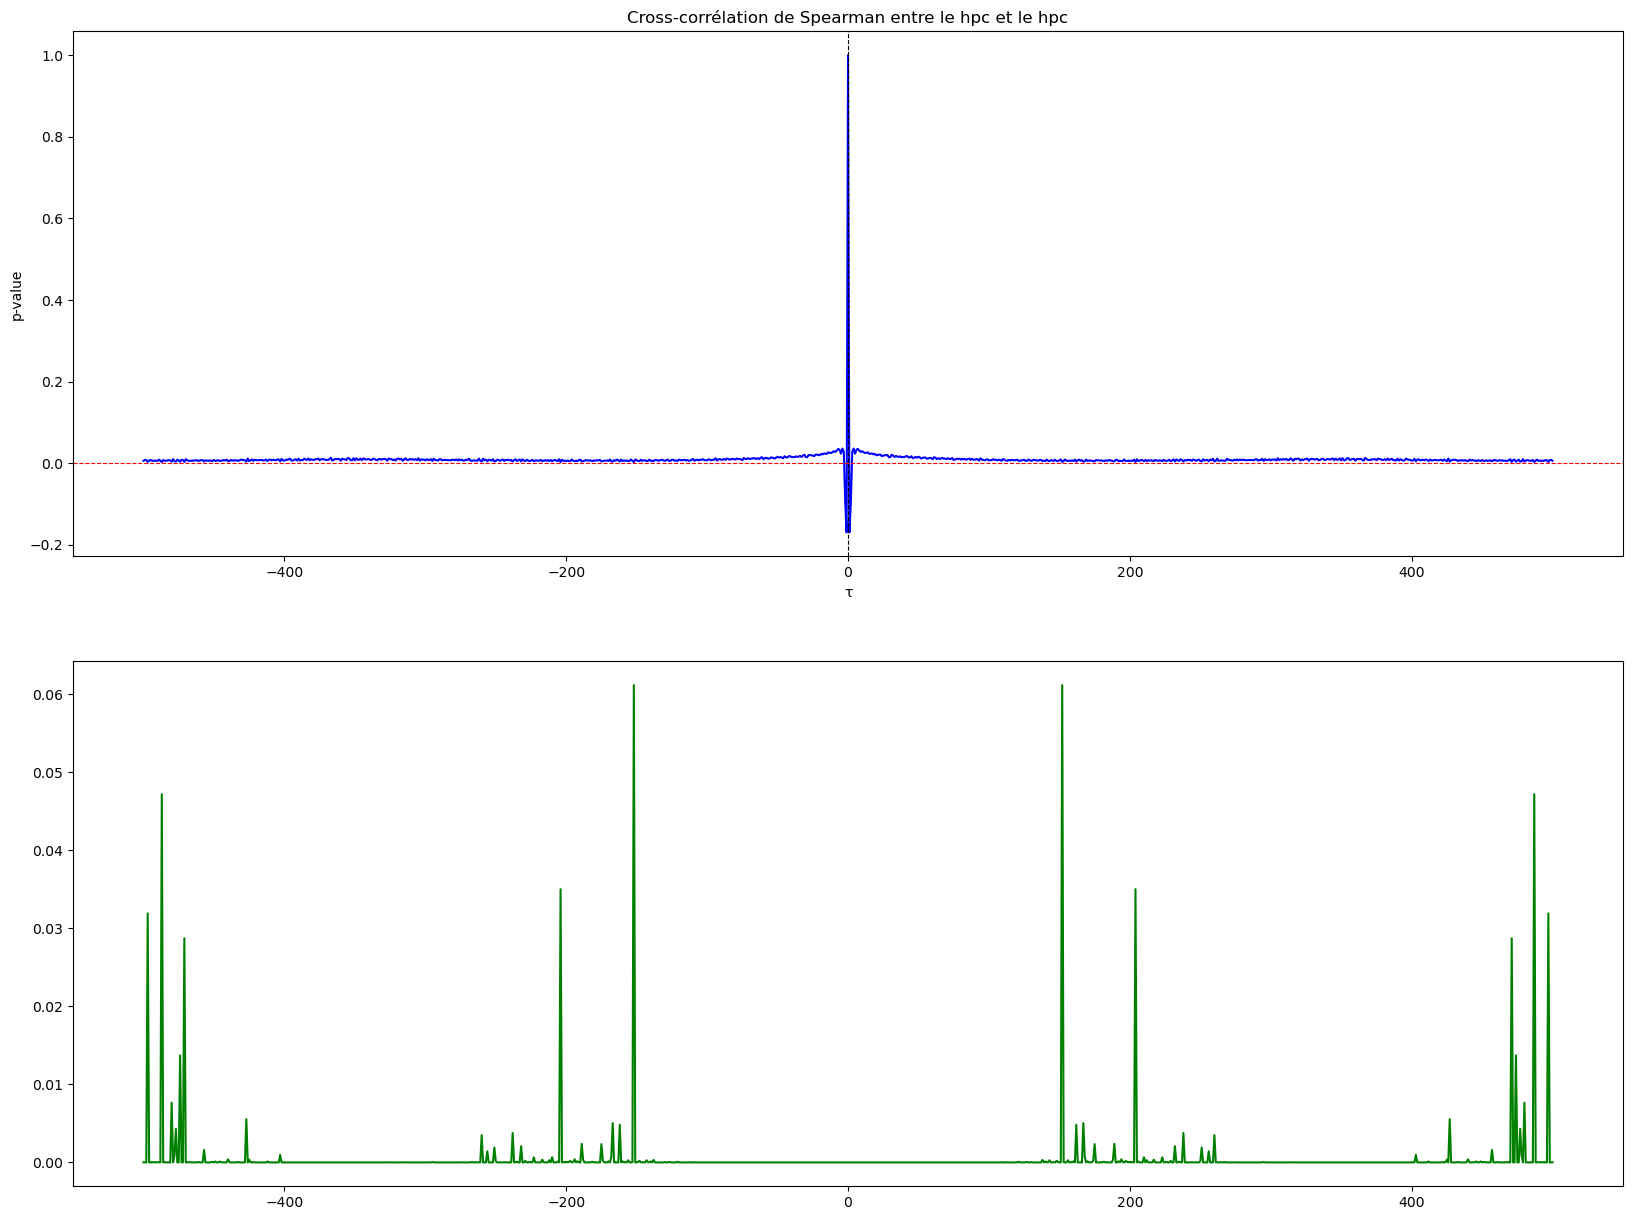

In [82]:
tm = 500
rgs = ['nr', 'pfc', 'hpc']
for i in range(len(rgs)):
    for j in range(i, len(rgs)):
        fig, axs = plt.subplots(2, 1, figsize=(20, 15))
        ax1, ax2 = axs.flatten()
        S1 = centered_size(size[rgs[i]], profiles[rgs[i]])
        S2 = centered_size(size[rgs[j]], profiles[rgs[j]])
        stat, pv, lags = SpearmanCorr(S1, S2, tm)
        plotSpearmanCorr(ax1, ax2 ,S1, S2, stat, pv, tm, threshold, rgs[i], rgs[j], f"Cross-corrélation de Spearman entre le {rgs[i]} et le {rgs[j]}")
        plt.show()

In [88]:
def overlap(a, b):
    # a = [[t1, t2], [t3, t4], ...]
    # b = [[t1, t2], [t3, t4], ...]
    a = np.array(a)
    b = np.array(b)
    
    total_overlap = 0
    for interval_a in a:
        for interval_b in b:
            start = max(interval_a[0], interval_b[0])
            stop  = min(interval_a[1], interval_b[1])
            if stop > start:  # il y a chevauchement
                total_overlap += stop - start
    return total_overlap

In [1]:
def overlap_vect(a, b):
    a = np.array(a)  # (n, 2)
    b = np.array(b)  # (m, 2)
    
    # broadcasting : (n, 1, 2) vs (1, m, 2)
    starts = np.maximum(a[:, None, 0], b[None, :, 0])  # (n, m)
    stops  = np.minimum(a[:, None, 1], b[None, :, 1])  # (n, m)
    
    return np.maximum(0, stops - starts).sum()

In [7]:
def overlap_opti(a, b):
    a = np.array(sorted(a, key=lambda x: x[0]))
    b = np.array(sorted(b, key=lambda x: x[0]))
    
    i, j = 0, 0
    total = 0
    
    while i < len(a) and j < len(b):
        start = max(a[i, 0], b[j, 0])
        stop  = min(a[i, 1], b[j, 1])
        if stop > start:
            total += stop - start
        # avancer le pointeur de l'intervalle qui se termine en premier
        if a[i, 1] < b[j, 1]:
            i += 1
        else:
            j += 1
    
    return total

In [8]:
a = [[0, 5], [8, 12], [15, 20]]
b = [[3, 9], [11, 17]]
overlap_opti(a,b)

np.int64(6)

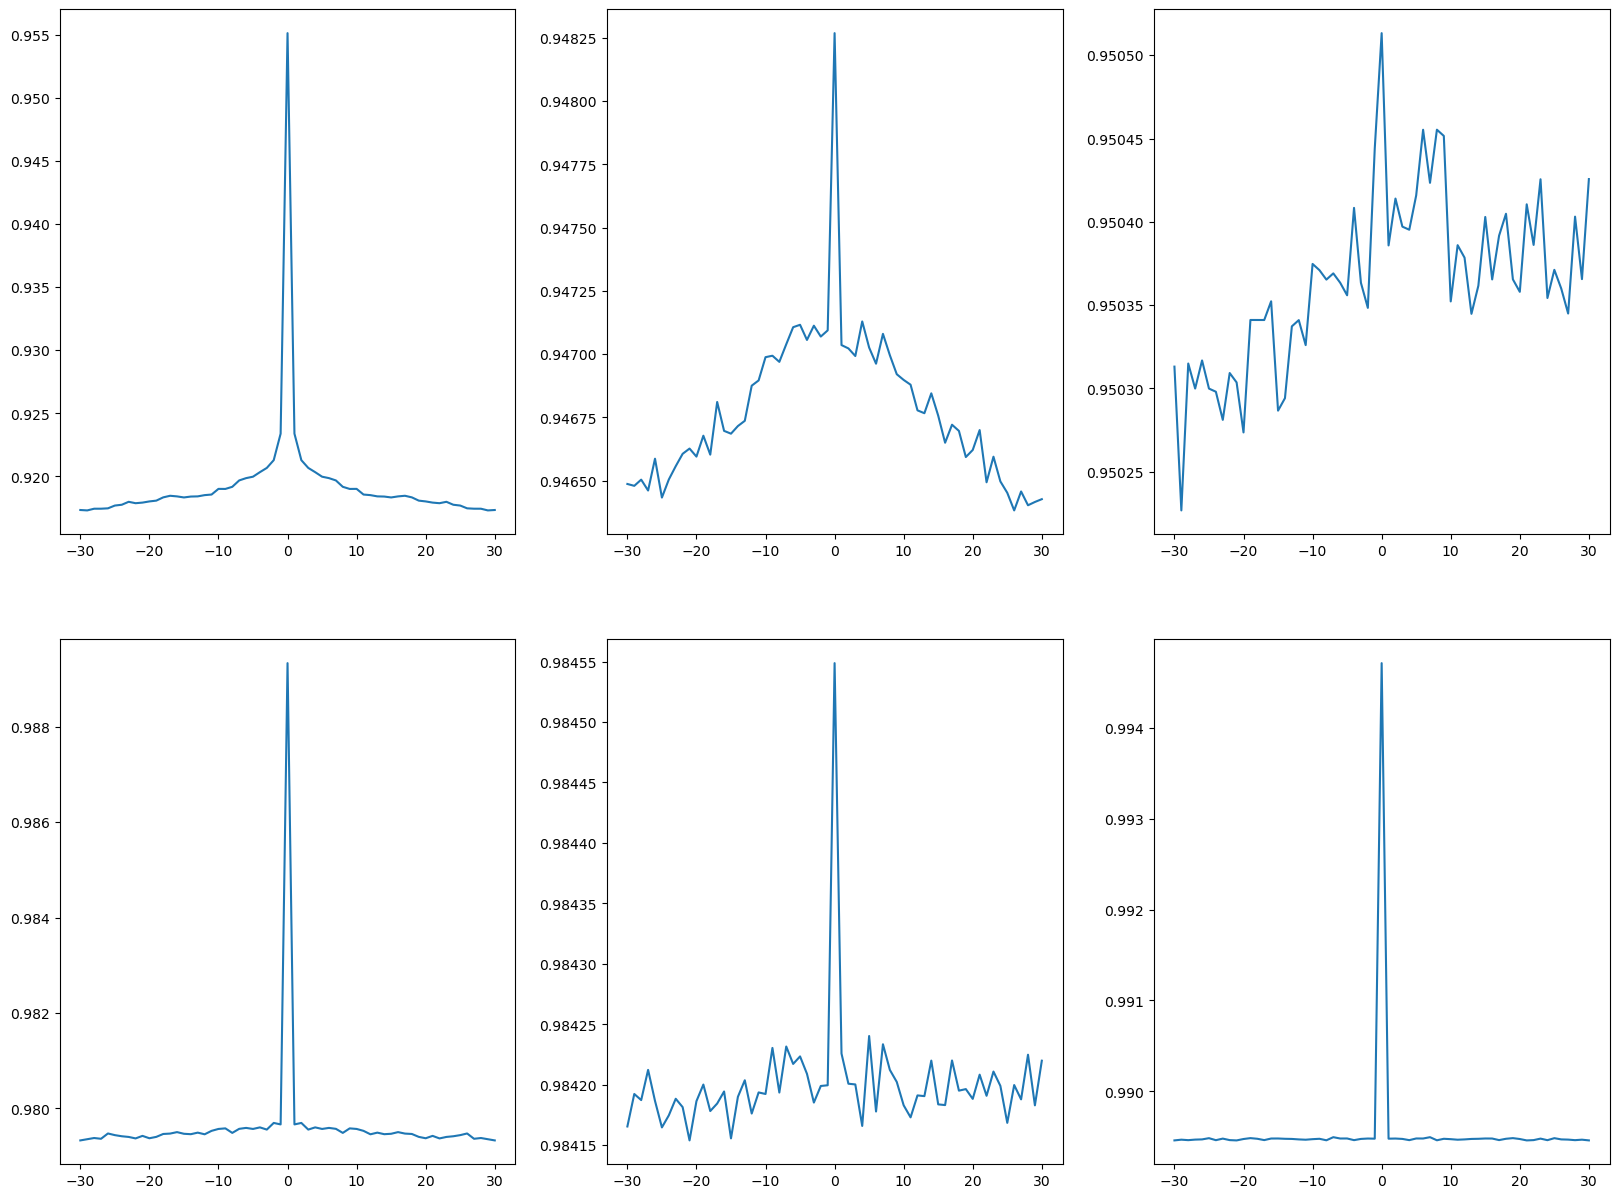

In [154]:
tm = 30
rgs = ['nr', 'pfc', 'hpc']
fig, axs = plt.subplots(2, 3, figsize=(20, 15))
n=0
for i in range(len(rgs)):
    for j in range(i, len(rgs)):
        ax = axs.flatten()[n]
        chev=[]
        time=[]  
        S1 = np.array(intervals[rgs[i]])
        S2 = np.array(intervals[rgs[j]])
        m1 = max(S1[:,1])
        m2 = max(S2[:,1])
        deb = min([S1[:,0].min(), S2[:,0].min()])
        for t in range(-tm, tm+1):
            if t >= 0:
                tot = min(m1-t, m2)
            else:
                tot = min(m2+t, m1)
            a = np.array(S1)
            b = np.array(S2)+t
            #chevauchement = overlap_opti(a,b)
            intersection = np.array(fma.general.intersectIntervals((a,b)))
            chevauchement = (intersection[:,1]-intersection[:,0]).sum()
            time.append(t)
            chev.append(chevauchement / tot)
        ax.plot(time, chev)
        n+=1
plt.show()